### **👩‍🏫 👩🏿‍🏫 What You'll learn**

- How to handle real-world healthcare data.
- Preprocessing data: Handling missing values, categorical variables, and feature scaling.
- Training a logistic regression model to predict the presence of heart disease.
- Evaluating the model's performance using accuracy, precision, recall, and the F1 score.

---

### **💼 Tools and Libraries Required**

- `Python`: A popular programming language for data analysis and machine learning.
- `scikit-learn`: Provides tools for data mining and data analysis, including logistic regression.
- `pandas`: For data manipulation and analysis.
- `matplotlib` and `seaborn`: For data visualization.
- Jupyter Notebook or any Python IDE.

### **Task**

Your task is to use the Heart Disease UCI dataset to predict whether or not a patient has heart disease based on various medical attributes.

1. Data Preparation:
    - Download the "Heart Disease UCI" dataset.
    - Perform exploratory data analysis (EDA) to understand the dataset.
    - Preprocess the data: handle missing values if any, encode categorical variables, and scale the features.
2. Model Training:
    - Split the dataset into a training set and a testing set.
    - Train a logistic regression model on the training set.
3. Model Evaluation:
    - Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.
    - Use a confusion matrix to visualize the model's performance.

### **Expected Deliverables**

A Jupyter Notebook containing:

- The EDA and preprocessing steps.
- The code for training and evaluating the logistic regression model.
- A confusion matrix and classification report for model evaluation.
- Any visualizations that helped you understand the dataset and the model's performance.


In [25]:
import glob
import os
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# extract the dataset zip to an output folder
ZIP_PATH = "UCI Heart Disease Data.zip"  # or your path
EXTRACT_DIR = "heart_ds"
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(EXTRACT_DIR)

csv_files = glob.glob(os.path.join(EXTRACT_DIR, "**", "*.csv"), recursive=True)

### Exploratory Data Analysis

Before touching anything, we will check data types, missing values and duplicates, and look at how the target (`num`) is distributed.


In [3]:
# list CSV files under EXTRACT_DIR
csv_path = csv_files[0]  # set to the CSV you choose

# load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# inspect df
print(df.shape)
display(df.head())

(920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.describe(include="all")

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [5]:
df.info()

print("\nMissing value % per column:")
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))

print(f"Duplicate rows: {df.duplicated().sum()}")

print("\nTarget distribution (num):")
print(df["num"].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing value % per column:
ca          66.4
thal        52.8
slope       33.6
fbs          9.8
oldpeak      6.7
trestbps     6.

In [6]:
df["chol"].value_counts()

,count
chol,
0.0,172
220.0,10
254.0,10
204.0,9
219.0,9
...,...
165.0,1
337.0,1
333.0,1


### Numeric Feature Distributions

Histograms for the five numeric features, to check shape (normal vs. skewed) before we decide anything about scaling.


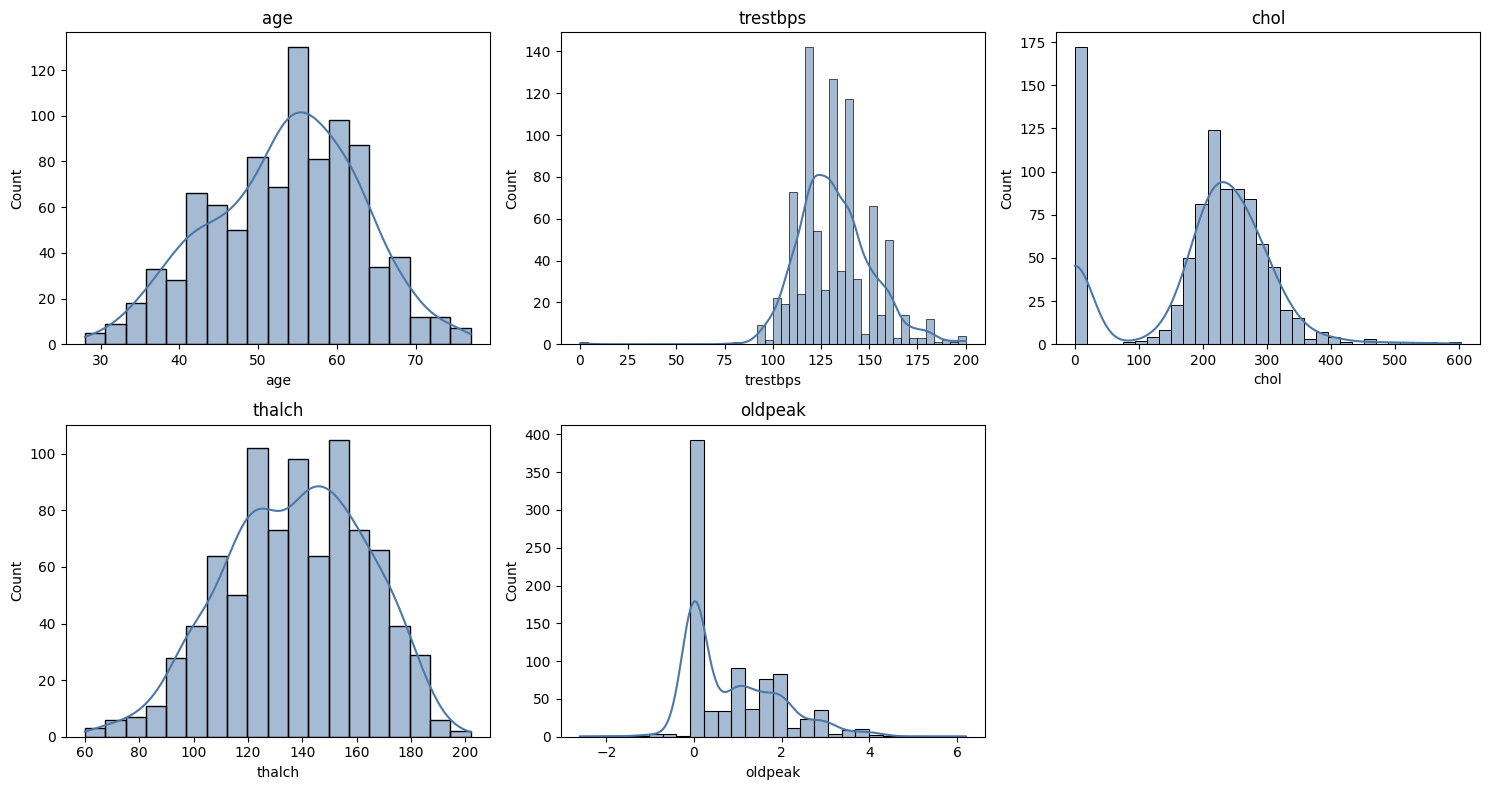

In [7]:
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C78A8")
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Categorical Feature Counts

Class balance for the categorical and boolean columns, before we encode anything.


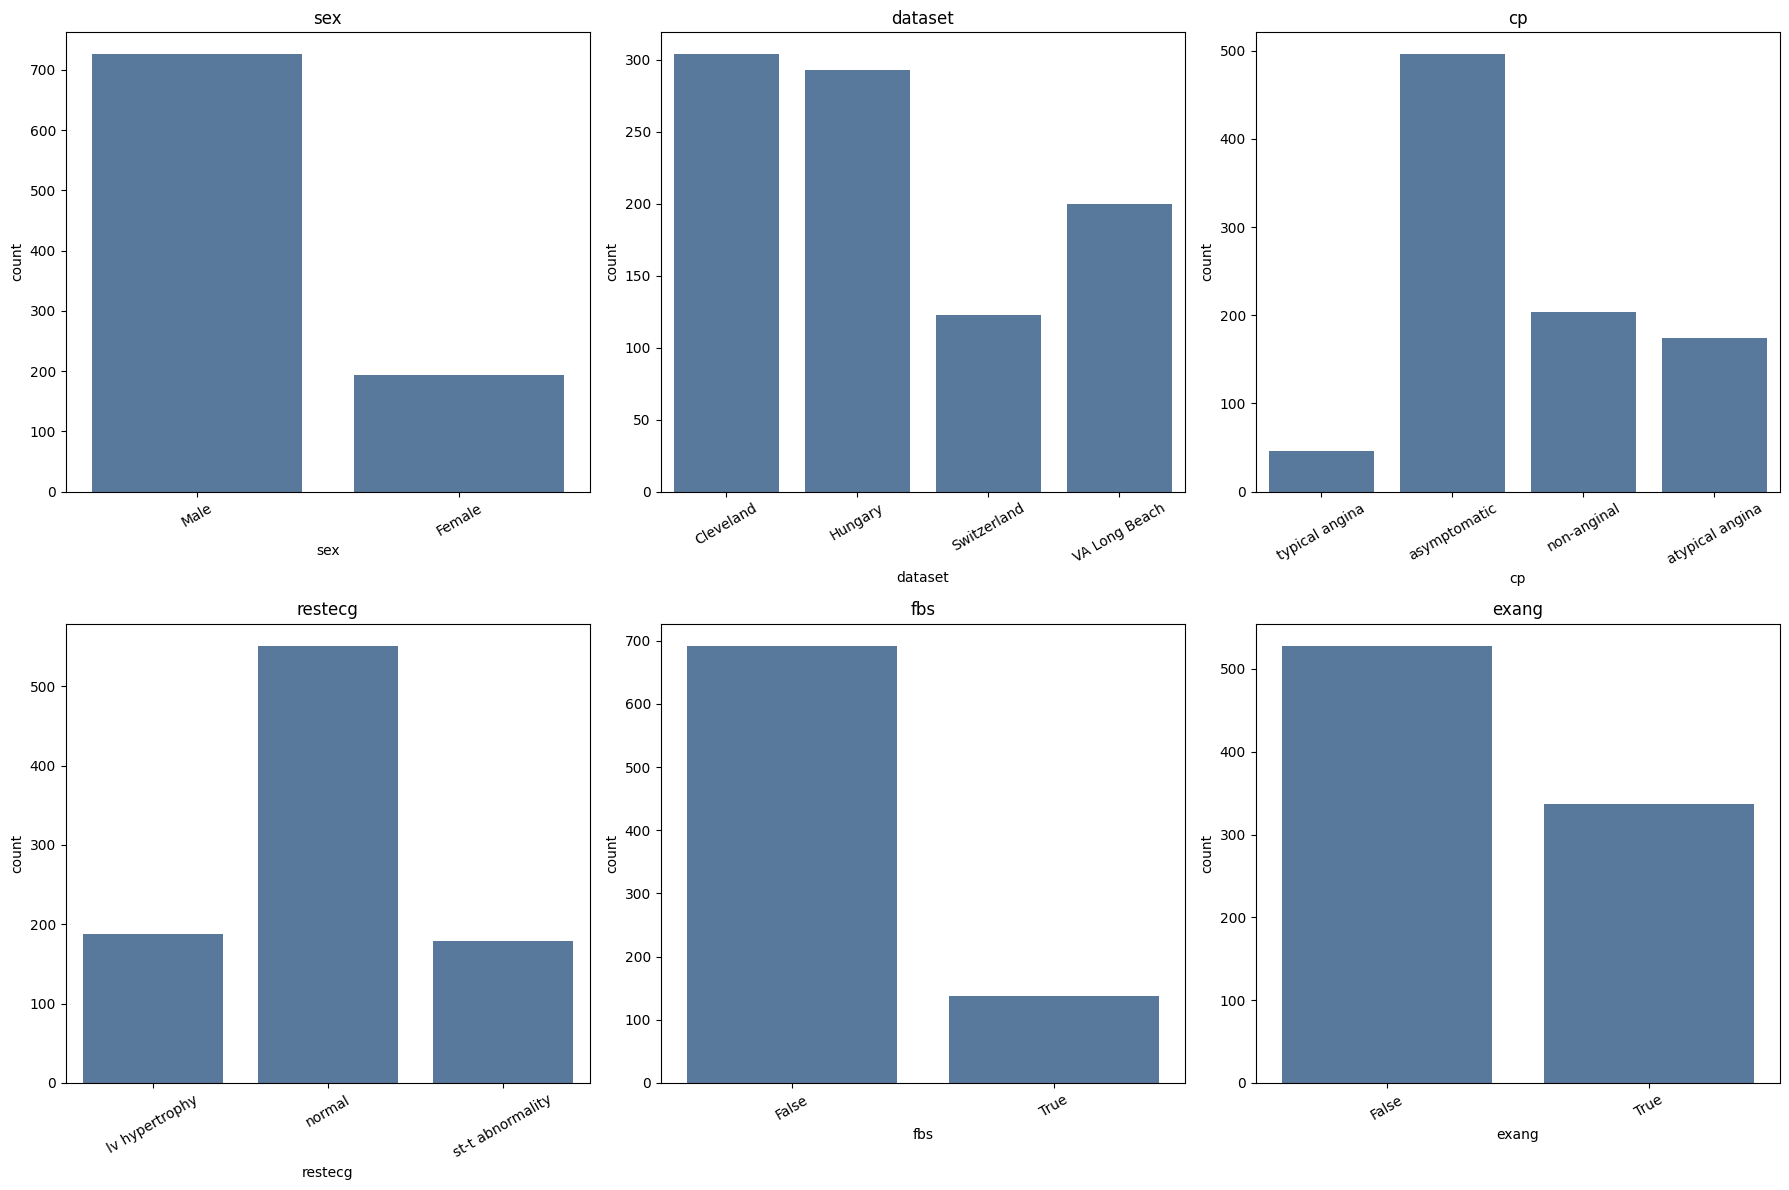

In [8]:
cat_cols = ["sex", "dataset", "cp", "restecg"]
bool_cols = ["fbs", "exang"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols + bool_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color="#4C78A8")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Correlation Between Numeric Features and Target

Checking for multicollinearity between predictors, and which numeric features correlate most with `num` (disease severity).


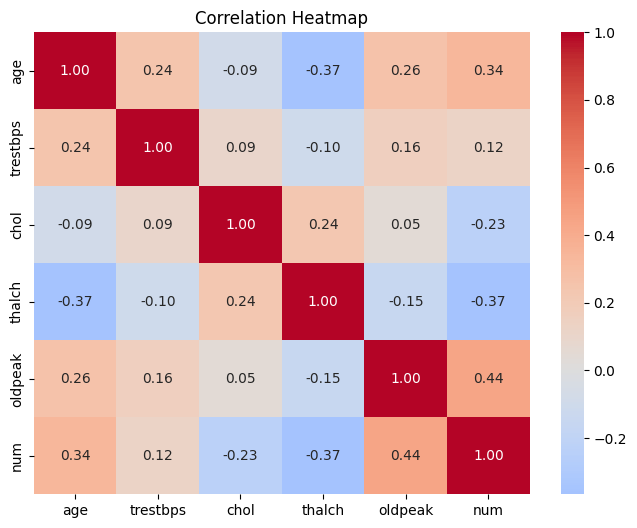

In [9]:
corr_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "num"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Handling Missing Values

`ca`, `thal`, and `slope` are missing on 33-66% of rows overall. Imputing them would mean fabricating values for most of the dataset, so we drop them instead and keep all 920 rows.
`dataset` is dropped since it is not a clinical attribute.

`chol` == 0 is not possible, because the body needs cholesterol to live and function properly. So we will treat `chol` 0 as missing.


In [10]:
df = df.drop(columns=["ca", "thal", "slope", "dataset"])

print("Remaining columns:", df.columns.tolist())
print("\nMissing value % per column:")
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))

Remaining columns: ['id', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'num']

Missing value % per column:
fbs         9.8
oldpeak     6.7
trestbps    6.4
thalch      6.0
exang       6.0
chol        3.3
restecg     0.2
id          0.0
cp          0.0
sex         0.0
age         0.0
num         0.0
dtype: float64


In [11]:
df["chol"] = df["chol"].replace(0, np.nan)

for col in ["trestbps", "chol", "thalch", "oldpeak"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["fbs", "exang", "restecg"]:
    df[col] = df[col].fillna(df[col].mode()[0]).infer_objects()

print(f"Missing values remaining:\n{df.isnull().sum().sort_values(ascending=False)}")

Missing values remaining:
id          0
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64


/tmp/ipykernel_2240/788224675.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0]).infer_objects()


### Creating the Binary Target

The task asks us to predict presence vs. absence of heart disease, but `num` is a 0-4 severity scale (411 rows at 0, 509 rows at 1-4). We collapse it into `target`: 0 = no disease, 1 = any disease present.


In [12]:
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num", "id"])

print(df["target"].value_counts(normalize=True).round(3))

target
1    0.553
0    0.447
Name: proportion, dtype: float64


### Encoding Categorical Variables

`sex`, `cp`, `restecg` are nominal categories, so we one-hot encode them (dropping first level each to avoid redundant / collinear columns). `fbs` and `exang` are already boolean, so we just cast them to int.


In [ ]:
for col in ["fbs", "exang"]:
    df[col] = df[col].astype(int)

df = pd.get_dummies(df, columns=["sex", "cp", "restecg"], drop_first=True)

print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(920, 14)
['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'target', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']
age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
target                      0
sex_Male                    0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
dtype: int64


### Train / Test Split

Splitting before scaling, so the scaler is fit only on the training set and just applied to the test set. This avoids leaking test-set information into training.


In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(736, 13) (184, 13)
target
1    0.553
0    0.447
Name: proportion, dtype: float64
target
1    0.554
0    0.446
Name: proportion, dtype: float64


### Feature Scaling

Logistic regression is distance / gradient-based, so features on very different scales (`age` ~29-77 vs `oldpeak` ~0-6) would let the larger scale ones dominate the loss. We standardize the numeric columns, fitting the scaler on the training set only.


In [21]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].describe().round(3)

,age,trestbps,chol,thalch,oldpeak
count,736.000,736.000,736.000,736.000,736.000
mean,-0.000,-0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-2.734,-2.911,-2.983,-2.970,-3.263
25%,-0.704,-0.675,-0.542,-0.707,-0.808
50%,0.044,-0.116,-0.104,0.088,-0.336
75%,0.685,0.442,0.395,0.683,0.608
max,2.501,3.796,6.671,2.550,5.046


### Training the Logistic Regression Model


In [23]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Model Evaluation


In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")

print(f"\n{classification_report(y_test, y_pred)}")

Accuracy: 0.799
Precision: 0.793
Recall: 0.863
F1 Score: 0.826

              precision    recall  f1-score   support

           0       0.81      0.72      0.76        82
           1       0.79      0.86      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.79      0.79       184
weighted avg       0.80      0.80      0.80       184



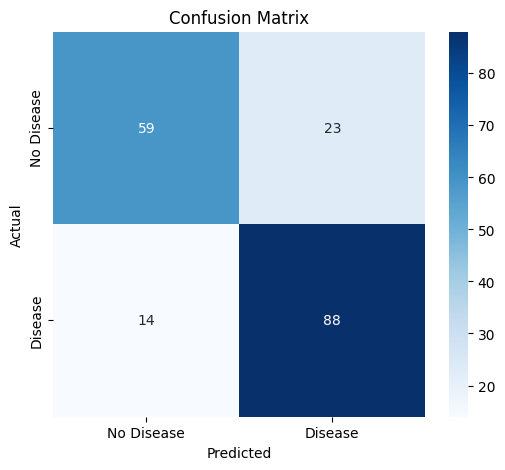

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Model Evaluation Conclusion

Recall at 86% (88 `TP` and 14 `FN`) means that the model correctly catches the large majority of actual disease cases, missing 14 out of 102. The model leans towards over-predicting disease rather than under-predicting it. For a medical screening context, that's probably the safer approach (a false alarm gets caught by follow-up testing, while a missing case doesn't).


In [30]:
coef_df = pd.DataFrame(
    {"feature": X_train.columns, "coefficient": model.coef_[0]}
).sort_values("coefficient", key=abs, ascending=False)

coef_df

,feature,coefficient
8,cp_atypical angina,-1.901815
7,sex_Male,1.419450
9,cp_non-anginal,-1.050647
5,exang,0.962233
10,cp_typical angina,-0.819993
6,oldpeak,0.500304
4,thalch,-0.409327
0,age,0.352133
3,fbs,0.274028
2,chol,0.246486


### Interpreting the Coefficients

The `cp_*` (chest pain type) dominate the model, but they're relative to `cp_asymptomatic` (the category `drop_first=True` dropped, so it's the implicit baseline). All three, `atypical angina` (-1.90), `non-anginal` (-1.05), and `typical angina` (-0.82), are negative. That means compared to a patient coded as having asymptomatic chest pain, having any of the actually-painful chest pain types is" associated with _lower_ odds of disease in this model. This matches a known pattern in this dataset: "asymptomatic" chest pain is the strongest single predictor of disease, stronger than any of the painful categories.

On `age / thalch`, both keep their expected direction and a meaningful weight once they're in the model together (`thalch`: -0.41, `age`: 0.35), so `thalch` isn't just standing in for `age`, it still adds some independent signal. `trestbps` (0.02), essentially contributing nothing, consistent with its near-zero (0.12) raw correlation with the target from the EDA heatmap.


### Final Conclusion

Logistic regression on the Heart Disease UCI dataset (920 patients, 4 combines study sites) reached 79.9% accuracy, with 79.3% precision and 86.3% recall on the disease-present class. The model leans toward over-predicting disease (23 `FP` vs. 14 `FN`), which is arguably the safer failure mode for a screening tool, though it comes at the cost of unnecessary follow-up for roughly 28% of healthy patients.

Key data decisions that shaped this result:

- `ca`, `thal`, and `slope` were dropped rather than imputed, since they were missing 33-66% of rows and missingness was structural (tied to study, not random). Imputing them would have meant fabricating values for most of the dataset.
- `chol == 0` (172 rows) was treated as missing rather than a real measurement, since cholesterol can't be zero. After replacing with the median, `chol`'s skew flipped from -0.61 to 1.57, consistent with a real, right-skewed cholesterol distribution.

The model's own coefficients back up its face validity: `cp_asymptomatic` chest pain (the reference category) carries the strongest association with disease of any `cp` category, matching a known pattern in this dataset, and `oldpeak` / `thalch` / `age`, the three strongest numeric correlates from the EDA, all kept meaningful, correctly-signed weights once combined in the model.
